# Gradient Boosting from First Principles (Step-by-Step, From Scratch)

## Purpose of This Notebook

This notebook is a **mechanistic, bottom-up reconstruction** of Gradient Boosting.

The goal is to understand — in precise, operational terms — how Gradient Boosting actually works. We will build the method step by step, starting from its simplest components and progressively introducing the ideas that lead to a full Gradient Boosting Machine (GBM).

The dataset used here (Lending Club loan data) is **only a working example**. It provides a realistic, structured environment, but the focus of this notebook is entirely on the **learning algorithm**, not the domain.

---

## Learning Strategy

We follow a strict progression:

1. **Single Decision Tree**

   * How trees partition the feature space
   * Impurity minimization (regression/classification)
   * Limitations: high variance, instability

2. **Bagging**

   * Bootstrap sampling
   * Variance reduction through averaging
   * Why independent noisy learners can be powerful

3. **Random Forest**

   * Feature subsampling
   * Tree decorrelation as a variance control mechanism

4. **Gradient Boosting**

   * Additive modeling
   * Residual fitting as a learning signal
   * Functional gradient descent perspective
   * Learning rate (shrinkage) and sequential dependence

Each step is motivated by a concrete limitation of the previous one.

---

## Implementation Philosophy

All key components will be implemented **from scratch using NumPy/Pandas**. This includes:

* Tree splitting logic
* Bootstrap sampling
* Ensemble aggregation
* Residual computation and updates

We deliberately avoid high-level libraries (e.g., `scikit-learn`, `XGBoost`, `LightGBM`) during the learning phase.

---

## What You Should Expect

* Work through the **exact mechanics** of each algorithm
* See how ensemble methods emerge from simple ideas
* Understand Gradient Boosting as an **optimization procedure**, not just a model

By the end, you should be able to derive and implement a GBM independently.

---

## Structure

The notebook is meant to be followed sequentially. Each section introduces a new concept, immediately grounded in code and experimentation.

---

Let’s begin with the fundamental building block: a single decision tree.


## Supervised Learning as Function Approximation

We start with the standard supervised learning setup.

We are given a dataset:

$$
{(x_i, y_i)}_{i=1}^{n}
$$

where:

* $x_i \in \mathbb{R}^p$ is a feature vector
* $y_i$ is the target (continuous for regression, binary for classification)

Our goal is to learn a function:

$$
f(x): \mathbb{R}^p \rightarrow \mathbb{R}
$$

that minimizes a loss function over the dataset:

$$
\mathcal{L}(f) = \sum_{i=1}^{n} \ell(y_i, f(x_i))
$$

---

## Choosing a Loss Function

The choice of loss function defines the learning problem:

**Regression (MSE)**
$$
\ell(y, f(x)) = (y - f(x))^2
$$

**Binary Classification (Log Loss)**
$$
\ell(y, f(x)) = -\left[y \log(p(x)) + (1 - y)\log(1 - p(x))\right]
$$

where:

$$
p(x) = \sigma(f(x))
$$

and $\sigma$ is the sigmoid function.

---

## Model Class: Why Trees?

Instead of directly optimizing over all possible functions $f$, we restrict ourselves to a class of functions.

In this notebook, we use **decision trees** as our base learners:

$$
f(x) \in \mathcal{F}_{\text{trees}}
$$

Trees are:

* Non-parametric
* Able to capture non-linear interactions
* Interpretable at small depth

However, they have a critical limitation:

> A single tree is typically a **weak and unstable estimator**.

---

## Strategy

Rather than trying to build one perfect model, we will:

* Start with a simple model $f_1(x)$
* Iteratively improve it
* Combine multiple models into a stronger predictor

This idea leads to **ensemble methods**.

---

## Roadmap to Gradient Boosting

We will build up to Gradient Boosting through increasingly sophisticated ensembles:

1. Fit a single tree
2. Reduce variance → **Bagging**
3. Decorrelate trees → **Random Forest**
4. Reduce bias sequentially → **Gradient Boosting**

The key conceptual shift will be:

> Instead of fitting models independently, we will fit models **sequentially to correct previous errors**.

---

## Decision Trees as Piecewise Constant Functions

First, we need a precise mathematical view of what a tree represents.

A decision tree partitions the feature space into disjoint regions:

$$
R_1, R_2, \dots, R_M
$$

and assigns a constant prediction to each region.

The model can therefore be written as:

$$
f(x) = \sum_{m=1}^{M} c_m \cdot \mathbf{1}(x \in R_m)
$$

where:

* $R_m$ are regions defined by recursive splits of the feature space
* $c_m$ is the prediction associated with region $R_m$
* $\mathbf{1}(\cdot)$ is the indicator function

---

## How Are the Regions Created?

The regions are constructed via **recursive binary splits** of the form:

$$
x_j \leq s
$$

where:

* $j$ is a feature index
* $s$ is a split threshold

Each split divides a region into two subregions, forming a tree structure.

---

## Learning a Tree = Solving an Optimization Problem

Training a tree consists of:

1. Choosing splits (feature $j$, threshold $s$)
2. Defining regions $R_m$
3. Estimating constants $c_m$

Formally, we aim to solve:

$$
\min_{{R_m, c_m}} \sum_{i=1}^{n} \ell\big(y_i, f(x_i)\big)
$$

---

## Optimal Prediction in Each Region

For a **fixed partition** ${R_m}$, the optimal constant in each region is:

* **Regression (MSE):**
  $$
  c_m = \frac{1}{|R_m|} \sum_{x_i \in R_m} y_i
  $$

* **Binary Classification (log loss):**
  $$
  c_m = \text{log-odds of the positive class in } R_m
  $$

This means:

> A tree is fully defined once we decide how to split the space.

---

## Key Limitation

Trees are:

* High variance (small changes in data → very different splits)
* Greedy (locally optimal splits, not globally optimal)

This will motivate ensemble methods shortly.

---

## What We Will Implement

We now implement a **regression tree from scratch**, focusing on:

* Finding the best split using MSE
* Recursively building the tree
* Stopping criteria (max depth, min samples)

This will serve as the foundation for all ensemble methods that follow.

---



## Step 1: Finding the Best Split (Classification Setting)

> Given a dataset, how do we find the **best binary split** for a classification problem?

---

## Problem Definition

Given:

* Features $X \in \mathbb{R}^{n \times p}$
* Target $y \in {0,1,\dots,K-1}^n$

We want to find:

* A feature $j$
* A threshold $s$

such that the split:

$$
R_{\text{left}} = {x \mid x_j \leq s}, \quad
R_{\text{right}} = {x \mid x_j > s}
$$

produces the **purest possible child nodes**.

---

## Node Impurity Measures

To evaluate a split, we quantify how “mixed” the classes are in each region.

Let $p_k$ be the proportion of class $k$ in a node.

### 1. Gini Impurity

$$
G = 1 - \sum_{k=1}^{K} p_k^2
$$

* Minimum: $0$ (pure node)
* Maximum: depends on $K$ (uniform distribution)
* Most commonly used in practice

---

### 2. Entropy

$$
H = - \sum_{k=1}^{K} p_k \log(p_k)
$$

* Measures uncertainty (information theory perspective)
* More sensitive to class imbalance than Gini

---

### 3. Classification Error

$$
E = 1 - \max_k p_k
$$

* Measures misclassification rate
* Less sensitive → rarely used for split selection

---

## Split Objective

For a candidate split $(j, s)$, we compute:

$$
\text{Impurity}(j, s) =
\frac{n_{\text{left}}}{n} \cdot I(R_{\text{left}})
+
\frac{n_{\text{right}}}{n} \cdot I(R_{\text{right}})
$$

where:

* $I(\cdot)$ is one of: Gini, Entropy, or Classification Error
* $n_{\text{left}}, n_{\text{right}}$ are node sizes

We choose the split that **minimizes this weighted impurity**.

---

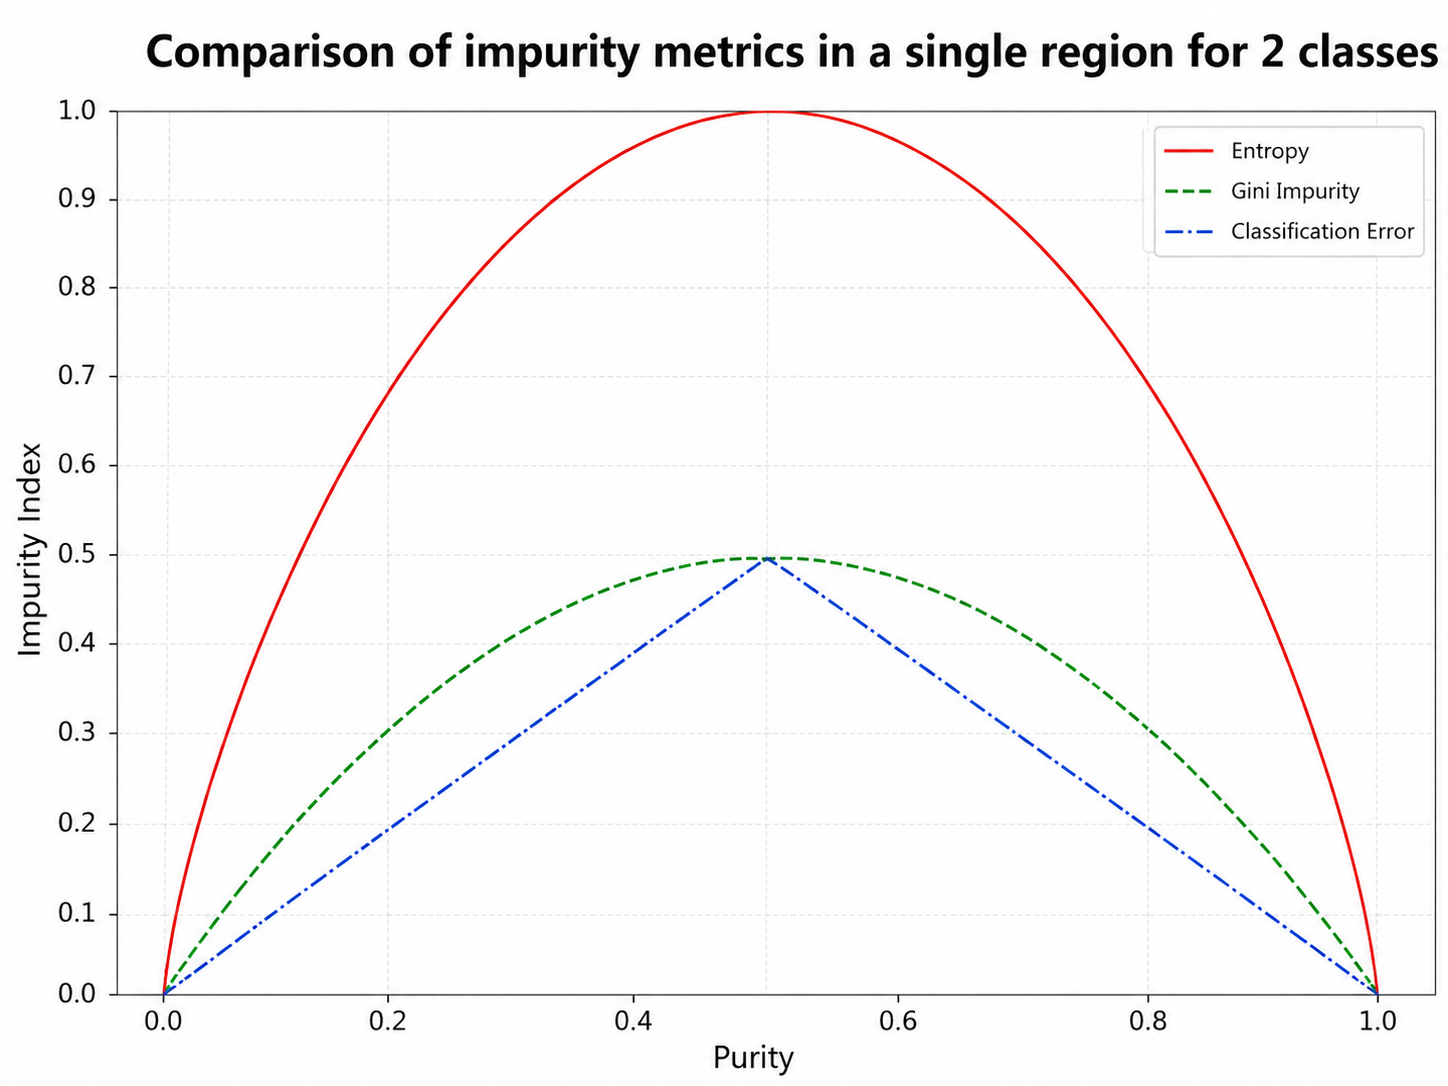

---
## What We Will Implement

We will build:

```python
def gini(y): ...
def entropy(y): ...
def classification_error(y): ...

def find_best_split(X, y, impurity_fn):
    ...
    return best_feature, best_threshold, best_impurity
```

This abstraction allows us to **swap impurity measures** and observe their effect.

---

## Important Note

These impurity measures are specific to **decision trees**.

Later, when we move to Gradient Boosting, we will switch to **differentiable loss functions** (e.g., log loss), enabling gradient-based optimization.

---

Let’s implement the impurity functions and the split search.



In [2]:
import numpy as np

# Gini vs Entropy → usually very similar splits
# Classification error → too coarse → poor split decisions
def class_proportions(y):
    _, counts = np.unique(y, return_counts=True)
    return counts / counts.sum()

def gini(y):
    p = class_proportions(y)
    return 1 - np.sum(p**2)

def entropy(y):
    p = class_proportions(y)
    p = p[p > 0]  # avoid log(0)
    return -np.sum(p * np.log(p))

def classification_error(y):
    p = class_proportions(y)
    return 1 - np.max(p)

def split_dataset(X, y, feature, threshold):
    left_mask = X[:, feature] <= threshold
    right_mask = ~left_mask
    return y[left_mask], y[right_mask]

def find_best_split(X, y, impurity_fn):
    n_samples, n_features = X.shape
    
    best_feature = None
    best_threshold = None
    best_impurity = float("inf")
    
    for j in range(n_features):
        values = np.unique(X[:, j])
        thresholds = (values[:-1] + values[1:]) / 2
        
        for s in thresholds:
            y_left, y_right = split_dataset(X, y, j, s)
            
            if len(y_left) == 0 or len(y_right) == 0:
                continue
            
            n = len(y)
            impurity = (
                len(y_left)/n * impurity_fn(y_left) +
                len(y_right)/n * impurity_fn(y_right)
            )
            
            if impurity < best_impurity:
                best_impurity = impurity
                best_feature = j
                best_threshold = s
    
    return best_feature, best_threshold, best_impurity

## Step 2: Building a Decision Tree (CART Classifier)

A tree is built **recursively**:

1. Find the best split at the current node
2. Partition the data into left and right subsets
3. Repeat the process on each subset

---

## Tree Structure

Each node in the tree will store:

* `feature` → index of the split feature
* `threshold` → split value
* `left` → left child node
* `right` → right child node
* `value` → predicted class (for leaf nodes)

---

## Stopping Criteria

To prevent infinite growth and overfitting, we stop splitting when:

* Maximum depth is reached
* Node has fewer than `min_samples_split` samples
* Node is already pure (only one class)

---

## Leaf Prediction

At a leaf node, we predict:

$$
\hat{y} = \arg\max_k p_k
$$

i.e., the **majority class** in that region.

---

## Training Algorithm

At each node:

1. Check stopping criteria
2. If stopping condition is met:

   * Create a leaf node
3. Otherwise:

   * Find best split using `find_best_split`
   * Recursively build left and right subtrees

---

## What We Will Implement

We will implement a minimal CART classifier:

```python
class DecisionTreeClassifier:
    def fit(self, X, y):
        ...

    def predict(self, X):
        ...
```

The implementation will be intentionally explicit to make the recursion and decision logic clear.

---

Once this is working, we will analyze its limitations—this will naturally lead us to Bagging.

Let’s implement it.


In [3]:
class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value  # only for leaf

    def is_leaf(self):
        return self.value is not None

class DecisionTreeClassifier:
    def __init__(self, max_depth=3, min_samples_split=2, impurity_fn=gini):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.impurity_fn = impurity_fn
        self.root = None
        self.n_classes_ = None

    def fit(self, X, y):
        self.n_classes_ = len(np.unique(y))
        self.root = self._grow_tree(X, y, depth=0)

    def _grow_tree(self, X, y, depth):
        n_samples = len(y)
        n_classes = len(np.unique(y))

        # stopping conditions
        if (
            depth >= self.max_depth or
            n_samples < self.min_samples_split or
            n_classes == 1
        ):
            return Node(value=self._class_proba(y))  # <-- store probabilities

        feature, threshold, _ = find_best_split(X, y, self.impurity_fn)

        if feature is None:
            return Node(value=self._class_proba(y))

        left_mask = X[:, feature] <= threshold
        right_mask = ~left_mask

        left_child = self._grow_tree(X[left_mask], y[left_mask], depth + 1)
        right_child = self._grow_tree(X[right_mask], y[right_mask], depth + 1)

        return Node(feature, threshold, left_child, right_child)

    def _class_proba(self, y):
        values, counts = np.unique(y, return_counts=True)
        proba = np.zeros(self.n_classes_)
        proba[values] = counts / counts.sum()
        return proba

    def predict_proba(self, X):
        return np.array([self._traverse_tree(x, self.root) for x in X])

    def predict(self, X):
        proba = self.predict_proba(X)
        return np.argmax(proba, axis=1)

    def _traverse_tree(self, x, node):
        if node.is_leaf():
            return node.value  # <-- now returns probability vector

        if x[node.feature] <= node.threshold:
            return self._traverse_tree(x, node.left)
        else:
            return self._traverse_tree(x, node.right)

In [4]:
# Test in real data
import pandas as pd
from sklearn.metrics import roc_auc_score, precision_score

# https://www.kaggle.com/datasets/wordsforthewise/lending-club/data
df_accepted_2007_to_2018Q4 = pd.read_csv('data/accepted_2007_to_2018Q4.csv', low_memory=False)
df = df_accepted_2007_to_2018Q4.sample(frac=0.02, random_state=1)  # The original data has 2,260,701 rows !!

# Format dates
date_cols = ["issue_d", "last_pymnt_d", "last_credit_pull_d"]
for c in date_cols:
    df[c] = pd.to_datetime(df[c], format="%b-%Y", errors="coerce")

# Define event properly
event_status = ["Charged Off", "Default"]
df["event"] = df["loan_status"].isin(event_status).astype(int)   # Charged Off = the lender has declared the loan unlikely to be collected and writes it off as a loss.

df["end_date"] = np.where(
    df["event"] == 1,
    df["last_pymnt_d"],
    df["last_credit_pull_d"]  # proxy for observation cutoff
)
df["end_date"] = pd.to_datetime(df["end_date"])

# Compute time-to-event (months)
def months_between(d1, d2):
    return (d2.dt.year - d1.dt.year) * 12 + (d2.dt.month - d1.dt.month)
df["t_event"] = months_between(df["issue_d"], df["end_date"])
# Clean invalid rows
df = df[(df["t_event"] >= 0) & (df["t_event"].notnull())]

df["term_months"] = df["term"].str.extract(r"(\d+)").astype(int)
df["t_event"] = np.minimum(df["t_event"], df["term_months"])

# default before maturity → event
# reaches maturity or still active → censored
df["event"] = np.where(
    (df["event"] == 1) & (df["t_event"] < df["term_months"]),
    1,
    0
)


# Format columns
df["int_rate"] = df["int_rate"].astype(str).str.replace("%", "").astype(float)
df["revol_util"] = df["revol_util"].astype(str).str.replace("%", "").astype(float)
df["emp_length"] = df["emp_length"].astype(str).str.extract(r"(\d+)").astype(float)

# New columns

if {"revol_bal", "loan_amnt"}.issubset(df.columns):
    df["credit_utilization"] = df["revol_bal"] / df["loan_amnt"]

if {"annual_inc", "loan_amnt"}.issubset(df.columns):
    df["income_to_loan"] = df["annual_inc"] / df["loan_amnt"]

if "issue_d" in df.columns:
    df["issue_year"] = df["issue_d"].dt.year


# Select just a few features to demo.     
num_cols = [
    "loan_amnt", "int_rate", "installment",
    "annual_inc", 
    "dti",
    "delinq_2yrs", "inq_last_6mths",
    "open_acc", "pub_rec",
    "revol_bal", "revol_util",
    "total_acc",
    "credit_utilization",
    "income_to_loan",
    "emp_length"
]

cat_cols = [
    "grade",
    "home_ownership",
    "verification_status",
    "purpose"
]

num_cols = [c for c in num_cols if c in df.columns]
cat_cols = [c for c in cat_cols if c in df.columns]


# Onehot
df_cat = pd.get_dummies(df[cat_cols], drop_first=True)

# Join categorical and continuous variables
df_model = pd.concat(
    [
        df[num_cols],
        df_cat,
        df[['id', 'issue_d', "t_event", "event"]]   # targets included here
    ],
    axis=1
)


df_model = df_model.dropna().reset_index(drop=True)

display(df_model)

,loan_amnt,int_rate,installment,annual_inc,dti,delinq_2yrs,inq_last_6mths,open_acc,pub_rec,revol_bal,...,purpose_moving,purpose_other,purpose_renewable_energy,purpose_small_business,purpose_vacation,purpose_wedding,id,issue_d,t_event,event
0,11000.0,10.90,359.61,36000.0,16.10,0.0,2.0,22.0,0.0,15093.0,...,False,False,False,False,False,False,132555889,2018-05-01,10.0,0
1,12000.0,6.99,370.48,86000.0,19.84,0.0,1.0,19.0,0.0,10032.0,...,False,False,False,False,False,False,69743499,2016-01-01,36.0,0
2,5000.0,12.05,166.20,25000.0,16.95,0.0,0.0,6.0,0.0,1312.0,...,False,False,False,False,False,False,63590274,2015-11-01,36.0,0
3,20000.0,15.61,699.30,40000.0,34.56,0.0,0.0,10.0,0.0,40605.0,...,False,False,False,False,False,False,42364040,2015-04-01,35.0,0
4,5000.0,18.94,183.13,68000.0,35.58,16.0,0.0,15.0,0.0,9301.0,...,False,False,False,False,False,False,144254317,2018-11-01,4.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42063,12775.0,15.41,445.42,100000.0,4.76,0.0,0.0,3.0,0.0,4104.0,...,False,False,False,False,False,False,65513585,2015-11-01,35.0,0
42064,21000.0,18.94,769.14,96000.0,6.36,1.0,1.0,8.0,0.0,5537.0,...,False,False,False,False,False,False,143648350,2018-12-01,3.0,0
42065,23000.0,19.99,609.24,46000.0,19.76,0.0,0.0,5.0,0.0,18482.0,...,False,False,False,False,False,False,51986451,2015-06-01,27.0,1
42066,14000.0,11.55,308.25,35300.0,35.12,0.0,0.0,8.0,0.0,16191.0,...,False,False,False,False,False,False,138376915,2018-08-01,7.0,0


In [5]:
df_model["event"].value_counts(normalize=True)

event
0    0.883356
1    0.116644
Name: proportion, dtype: float64

In [6]:
# Separates train and test
# Ensure datetime
df_model["issue_d"] = pd.to_datetime(df_model["issue_d"])


# 80/20 - with out0of-time test
cutoff_date = df_model["issue_d"].quantile(0.8)

print("Cutoff date:", cutoff_date)


df_model["split"] = np.where(
    df_model["issue_d"] < cutoff_date,
    "train",
    "test"
)

df_model['split'].value_counts()

Cutoff date: 2018-01-01 00:00:00


split
train    33063
test      9005
Name: count, dtype: int64

In [7]:
df_train = df_model[np.isin(df_model['split'], 'train')]
df_test = df_model[np.isin(df_model['split'], 'test')]

target = "event"

# Remove some cols to run it faster.
feature_cols = [
    'loan_amnt', 'int_rate', 
    # 'installment', 
    # 'annual_inc', 
    'dti', 
    # 'delinq_2yrs', 'inq_last_6mths', 
    # 'open_acc', 'pub_rec',
    # 'revol_bal', 'revol_util', 
    # 'total_acc', 
    'credit_utilization', 'income_to_loan', 
    # 'emp_length', 
    # 'grade_B', 'grade_C', 'grade_D', 'grade_E', 
    'grade_F', 'grade_G', 
    # 'home_ownership_MORTGAGE', 'home_ownership_NONE', 'home_ownership_OTHER', 'home_ownership_OWN', 'home_ownership_RENT', 
    'verification_status_Source Verified', 'verification_status_Verified',
    # 'purpose_credit_card', 'purpose_debt_consolidation', 'purpose_educational', 'purpose_home_improvement', 'purpose_house',
    # 'purpose_major_purchase', 'purpose_medical', 'purpose_moving', 'purpose_other', 'purpose_renewable_energy',
    # 'purpose_small_business', 'purpose_vacation', 'purpose_wedding'
]

X_train = df_train[feature_cols].values
y_train = df_train[target].astype(int).values

X_test = df_test[feature_cols].values
y_test = df_test[target].astype(int).values


tree = DecisionTreeClassifier(max_depth=2)
tree.fit(X_train, y_train)

preds_train_tree = tree.predict_proba(X_train)
preds_test_tree = tree.predict_proba(X_test)

auc_train_tree = roc_auc_score(y_train, preds_train_tree[:,1])
auc_test_tree = roc_auc_score(y_test, preds_test_tree[:,1])

print("Tree auc:", auc_test_tree)

Tree auc: 0.6634159577798507


## Step 3: Bagging (Bootstrap Aggregation)

A single decision tree is a **high-variance estimator**:

* Small changes in the data can lead to very different splits
* This instability leads to overfitting

---

## Core Idea

Instead of training one tree, we train **many trees on different bootstrap samples** and average their predictions.

---

## Bootstrap Sampling

Given a dataset of size $n$, a bootstrap sample is created by:

* Sampling $n$ observations **with replacement**

This means:

* Some observations appear multiple times
* Some observations are not selected at all

Each tree sees a **slightly different dataset**.

---

## Bagging Algorithm

For $b = 1, \dots, B$:

1. Sample a bootstrap dataset $D_b$
2. Train a decision tree $f_b(x)$ on $D_b$

Final prediction:

* **Classification (majority vote):**
  $$
  \hat{y} = \text{mode} \left( f_1(x), f_2(x), \dots, f_B(x) \right)
  $$

---

## Why This Works

If individual trees have:

* High variance
* Low bias

Then averaging them:

* Reduces variance
* Keeps bias roughly unchanged

The key requirement:

> The trees must be **diverse (uncorrelated)**.

Bootstrap sampling introduces this diversity.

---

## Important Limitation

Bagging reduces variance, but:

* If trees are highly correlated, gains are limited
* Strong predictors dominate splits → trees become similar

This limitation motivates **Random Forest**, where we explicitly decorrelate trees.

---

## What We Will Implement

We wrap our existing tree into an ensemble:

```python id="7qg9kx"
class BaggingClassifier:
    def fit(self, X, y):
        ...

    def predict(self, X):
        ...
```

Each model is an independent `DecisionTreeClassifier`.

---

Let’s implement Bagging.


In [8]:
def bootstrap_sample(X, y):
    n_samples = X.shape[0]
    indices = np.random.choice(n_samples, size=n_samples, replace=True)
    return X[indices], y[indices]

class BaggingClassifier:
    def __init__(self, n_estimators=10, max_depth=3, min_samples_split=2, impurity_fn=gini):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.impurity_fn = impurity_fn
        self.models = []

    def fit(self, X, y):
        self.models = []

        for _ in range(self.n_estimators):
            X_sample, y_sample = bootstrap_sample(X, y)

            tree = DecisionTreeClassifier(
                max_depth=self.max_depth,
                min_samples_split=self.min_samples_split,
                impurity_fn=self.impurity_fn
            )

            tree.fit(X_sample, y_sample)
            self.models.append(tree)

    def predict_proba(self, X):
        # shape: (n_estimators, n_samples, n_classes)
        probas = np.array([model.predict_proba(X) for model in self.models])

        # average across estimators
        return np.mean(probas, axis=0)

    def predict(self, X):
        proba = self.predict_proba(X)
        return np.argmax(proba, axis=1)

In [9]:
bagging = BaggingClassifier(n_estimators=50, max_depth=3)
bagging.fit(X_train, y_train)

preds_train_bag = bagging.predict_proba(X_train)
preds_test_bag = bagging.predict_proba(X_test)

auc_train_bag = roc_auc_score(y_train, preds_train_bag[:,1])
auc_test_bag = roc_auc_score(y_test, preds_test_bag[:,1])

print("Tree auc:", auc_test_tree)
print("Bagging auc:", auc_test_bag)

Tree auc: 0.6634159577798507
Bagging auc: 0.7003875901238413


## Step 4: Random Forest (Decorrelating Trees)

In Bagging, we reduced variance by averaging multiple trees trained on bootstrap samples.

However, there is still a key limitation:

> If some features are very strong predictors, most trees will use them in their top splits → trees become highly correlated.

---

## Core Idea

Random Forest introduces **feature randomness** to decorrelate trees.

At each split, instead of considering all features, we:

* Randomly select a subset of features
* Search for the best split **only within this subset**

---

## Algorithm Modification

Compared to Bagging, the only change is:

At each node:

1. Sample $m$ features (without replacement)
2. Run `find_best_split` only on those features

---

## Typical Choice of $m$

For classification:

$$
m \approx \sqrt{p}
$$

where $p$ is the total number of features.

---

## Why This Works

* Forces trees to explore different structures
* Reduces correlation between trees
* Improves variance reduction when averaging

---

## Relationship to Bagging

Random Forest = Bagging + Feature Subsampling

---

## What We Will Implement

We will **modify our existing tree**, adding feature subsampling at each split.

Then we reuse the same Bagging structure.

---

Let’s implement this modification.


In [10]:
# Modify find_best_split to add feature subsampling.
def find_best_split(X, y, impurity_fn, feature_indices=None):
    n_samples, n_features = X.shape

    if feature_indices is None:
        feature_indices = range(n_features)

    best_feature = None
    best_threshold = None
    best_impurity = float("inf")

    for j in feature_indices:
        values = np.unique(X[:, j])
        thresholds = (values[:-1] + values[1:]) / 2

        for s in thresholds:
            y_left, y_right = split_dataset(X, y, j, s)

            if len(y_left) == 0 or len(y_right) == 0:
                continue

            n = len(y)
            impurity = (
                len(y_left)/n * impurity_fn(y_left) +
                len(y_right)/n * impurity_fn(y_right)
            )

            if impurity < best_impurity:
                best_impurity = impurity
                best_feature = j
                best_threshold = s

    return best_feature, best_threshold, best_impurity


# Add max_features.
import numpy as np

class DecisionTreeClassifier:
    def __init__(
        self,
        max_depth=3,
        min_samples_split=2,
        impurity_fn=gini,
        max_features=None
    ):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.impurity_fn = impurity_fn
        self.max_features = max_features
        self.root = None
        self.n_classes_ = None

    def fit(self, X, y):
        self.n_classes_ = len(np.unique(y))
        self.root = self._grow_tree(X, y, depth=0)

    def _grow_tree(self, X, y, depth):
        n_samples, n_features = X.shape
        n_classes = len(np.unique(y))

        # stopping conditions
        if (
            depth >= self.max_depth or
            n_samples < self.min_samples_split or
            n_classes == 1
        ):
            return Node(value=self._class_proba(y))  # <-- store probabilities

        # feature subsampling (for RF compatibility)
        if self.max_features is None:
            feature_indices = np.arange(n_features)
        else:
            feature_indices = np.random.choice(
                n_features,
                size=self.max_features,
                replace=False
            )

        feature, threshold, _ = find_best_split(
            X, y, self.impurity_fn, feature_indices
        )

        if feature is None:
            return Node(value=self._class_proba(y))

        left_mask = X[:, feature] <= threshold
        right_mask = ~left_mask

        left_child = self._grow_tree(X[left_mask], y[left_mask], depth + 1)
        right_child = self._grow_tree(X[right_mask], y[right_mask], depth + 1)

        return Node(feature, threshold, left_child, right_child)

    def _class_proba(self, y):
        values, counts = np.unique(y, return_counts=True)
        proba = np.zeros(self.n_classes_)
        proba[values] = counts / counts.sum()
        return proba

    def predict_proba(self, X):
        return np.array([self._traverse_tree(x, self.root) for x in X])

    def predict(self, X):
        proba = self.predict_proba(X)
        return np.argmax(proba, axis=1)

    def _traverse_tree(self, x, node):
        if node.is_leaf():
            return node.value  # probability vector

        if x[node.feature] <= node.threshold:
            return self._traverse_tree(x, node.left)
        else:
            return self._traverse_tree(x, node.right)

class RandomForestClassifier:
    def __init__(self, n_estimators=50, max_depth=3, max_features=None):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.max_features = max_features
        self.models = []

    def fit(self, X, y):
        self.models = []

        for _ in range(self.n_estimators):
            X_sample, y_sample = bootstrap_sample(X, y)

            tree = DecisionTreeClassifier(
                max_depth=self.max_depth,
                max_features=self.max_features
            )

            tree.fit(X_sample, y_sample)
            self.models.append(tree)

    def predict_proba(self, X):
        # shape: (n_estimators, n_samples, n_classes)
        probas = np.array([model.predict_proba(X) for model in self.models])

        # average across trees
        return np.mean(probas, axis=0)

    def predict(self, X):
        proba = self.predict_proba(X)
        return np.argmax(proba, axis=1)

In [11]:
# Bagging reduces variance
# Random Forest reduces variance + correlation
rf = RandomForestClassifier(
    n_estimators=50,
    max_depth=5,
    max_features=int(np.sqrt(X_train.shape[1]))
)

rf.fit(X_train, y_train)
preds_train_rf = rf.predict_proba(X_train)
preds_test_rf = rf.predict_proba(X_test)

auc_train_rf = roc_auc_score(y_train, preds_train_rf[:,1])
auc_test_rf = roc_auc_score(y_test, preds_test_rf[:,1])

print("Tree auc:", auc_test_tree)
print("Bagging auc:", auc_test_bag)
print("RF auc:", auc_test_rf)

Tree auc: 0.6634159577798507
Bagging auc: 0.7003875901238413
RF auc: 0.6988620201407021


## Step 5: From Averaging to Sequential Learning

So far, all ensemble methods we built follow the same principle:

> Train many models independently and **average** their predictions.

This reduces variance, but it does **not directly address bias**.

---

## A Different Idea

Instead of training models independently, we build them **sequentially**:

* Start with a simple model
* Add new models that **correct the errors** of the current model

We construct an additive model:

$$
f(x) = \sum_{m=1}^{M} f_m(x)
$$

where each $f_m(x)$ is a small decision tree.

---

## Key Question

How do we choose each new function $f_m(x)$?

---

## Optimization Perspective

Recall our objective:

$$
\mathcal{L}(f) = \sum_{i=1}^{n} \ell(y_i, f(x_i))
$$

We want to minimize this loss.

Instead of solving this in one step, we proceed **iteratively**:

At step $m$:

* We already have a model $f_{m-1}(x)$
* We want to find a new function $f_m(x)$ that improves it

---

## Gradient Descent in Function Space

In standard optimization, we update parameters using gradients.

Here, we do something analogous:

> We move in the direction of the **negative gradient of the loss with respect to the predictions**.

For each observation:

$$
r_i^{(m)} = - \left.\frac{\partial \ell(y_i, f(x_i))}{\partial f(x_i)}\right|*{f = f*{m-1}}
$$

These values $r_i^{(m)}$ are called:

> **pseudo-residuals**

---

## Key Idea

At each step:

1. Compute pseudo-residuals
2. Fit a decision tree to predict these residuals
3. Add this tree to the model

---

## Special Case: Squared Error

If:

$$
\ell(y, f(x)) = (y - f(x))^2
$$

then:

$$
r_i = y_i - f(x_i)
$$

i.e., the residuals are exactly the usual residuals.

---

## What Changes for Classification?

For classification (log loss), residuals are:

* Not simple differences
* Derived from the gradient of the loss

This is why Gradient Boosting is fundamentally an **optimization algorithm**, not just a modeling trick.

---


## Step 6: Gradient Boosting for Classification (Log Loss)

## Model Representation

Instead of directly predicting probabilities, we model:

$$
f(x) \in \mathbb{R}
$$

and map it to a probability using the sigmoid function:

$$
p(x) = \sigma(f(x)) = \frac{1}{1 + e^{-f(x)}}
$$

---

## Loss Function (Log Loss)

We minimize the binary cross-entropy:

$$
\ell(y, f(x)) =
\left[
  y \log(p(x)) + (1 - y)\log(1 - p(x))
  \right]
  $$

---

## Key Insight: We Optimize in Logit Space

We are not directly updating probabilities.

Instead, we build an additive model:

$$
f(x) = \sum_{m=1}^{M} f_m(x)
$$

and only at the end compute:

$$
p(x) = \sigma(f(x))
$$

---

## Pseudo-Residuals for Log Loss

We compute the gradient of the loss with respect to (f(x)):

$$
r_i^{(m)} =
\frac{\partial \ell(y_i, f(x_i))}{\partial f(x_i)}
  $$

For log loss, this simplifies to:

$$
r_i = y_i - p_i
$$

where:

$$
p_i = \sigma(f(x_i))
$$

---

## Important Interpretation

This looks like a residual, but it is not:
$$
(y_i \in {0,1})
$$
$$
(p_i \in [0,1])
$$
So:

> We are fitting trees to **probability errors**, not label errors.

---

## Algorithm (Classification GBM)

Initialize:

$$
f_0(x) = \text{log-odds of the dataset}
$$

For $m = 1, \dots, M$:

1. Compute probabilities:
   $$
   p_i = \sigma(f_{m-1}(x_i))
   $$

2. Compute pseudo-residuals:
   $$
   r_i = y_i - p_i
   $$

3. Fit a tree $h_m(x)$ to predict $r_i$

4. Update:
   $$
   f_m(x) = f_{m-1}(x) + \eta \cdot h_m(x)
   $$

where:

* $\eta$ = learning rate (shrinkage)

---

## Initialization (Critical Detail)

We start with a constant model:

$$
f_0 = \log\left(\frac{\bar{y}}{1 - \bar{y}}\right)
$$

where $\bar{y}$ is the mean of the target.

This ensures:

* Initial prediction = base rate probability

---

## Why This Works

* Each tree approximates the **gradient direction**
* The model improves via **functional gradient descent**
* Small steps (learning rate) prevent overfitting

---

## Why Gradient Boosting Uses Trees (Not Random Forests)

At this stage, it may seem natural to reuse the Random Forest we just built.

However, Gradient Boosting requires a fundamentally different type of learner.

* Random Forest is a **strong ensemble model**
* Gradient Boosting requires **weak learners** that make small corrections

Each step in boosting must:

* Approximate the gradient
* Make a controlled update (via the learning rate)

Using a complex model like Random Forest would:

* Over-correct errors
* Break the optimization process

For this reason, Gradient Boosting uses **small decision trees (typically shallow)** as base learners.

Additionally:

* Trees now predict **continuous residuals**, not class labels
* Therefore, we use **regression trees**, even for classification problems

This shift—from predicting labels to predicting gradients—is the core idea behind Gradient Boosting.

---
## What We Will Implement

We now implement:

```python id="k9n4pz"
class GradientBoostingClassifier:
    def fit(self, X, y):
        ...

    def predict_proba(self, X):
        ...

    def predict(self, X):
        ...
```

Key components:

* Sigmoid function
* Log-odds initialization
* Residual computation: (y - p)
* Sequential tree fitting

---

Let’s implement it step by step.


In [12]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

class GradientBoostingClassifier:
    def __init__(self, n_estimators=50, learning_rate=0.1, max_depth=3):
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.max_depth = max_depth
        self.models = []
        self.init_value = None

    def fit(self, X, y):
        self.models = []

        # initial log-odds
        p = np.clip(np.mean(y), 1e-6, 1 - 1e-6)
        self.init_value = np.log(p / (1 - p))

        # initial prediction
        f = np.full(len(y), self.init_value)

        for _ in range(self.n_estimators):
            p = sigmoid(f)

            # pseudo-residuals
            residuals = y - p

            tree = DecisionTreeRegressor(max_depth=self.max_depth)
            tree.fit(X, residuals)

            update = tree.predict(X)

            f += self.learning_rate * update

            self.models.append(tree)

    def predict_proba(self, X):
        f = np.full(X.shape[0], self.init_value)

        for model in self.models:
            f += self.learning_rate * model.predict(X)

        p = sigmoid(f)
        return np.vstack([1 - p, p]).T

    def predict(self, X):
        proba = self.predict_proba(X)[:, 1]
        return (proba >= 0.5).astype(int)

In [13]:
'''
## Why We Use Regression Trees in Classification Boosting

Although the task is classification, Gradient Boosting fits trees to **continuous residuals (gradients)**.

Therefore, each tree is a **regression model**, not a classifier.

This is a key conceptual shift:

* Trees no longer predict class labels
* They approximate the direction in which the model should improve
'''
def mse(y):
    return np.mean((y - np.mean(y))**2)

def find_best_split_regression(X, y):
    n_samples, n_features = X.shape

    best_feature = None
    best_threshold = None
    best_loss = float("inf")

    for j in range(n_features):
        values = np.unique(X[:, j])
        thresholds = (values[:-1] + values[1:]) / 2

        for s in thresholds:
            left = y[X[:, j] <= s]
            right = y[X[:, j] > s]

            if len(left) == 0 or len(right) == 0:
                continue

            loss = (
                len(left)/n_samples * mse(left) +
                len(right)/n_samples * mse(right)
            )

            if loss < best_loss:
                best_loss = loss
                best_feature = j
                best_threshold = s

    return best_feature, best_threshold, best_loss
    
class DecisionTreeRegressor:
    def __init__(self, max_depth=3, min_samples_split=2):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.root = None

    def fit(self, X, y):
        self.root = self._grow_tree(X, y, depth=0)

    def _grow_tree(self, X, y, depth):
        n_samples, n_features = X.shape

        # stopping conditions
        if (
            depth >= self.max_depth or
            n_samples < self.min_samples_split
        ):
            return Node(value=np.mean(y))  # <-- key difference

        feature, threshold, _ = find_best_split_regression(X, y)

        if feature is None:
            return Node(value=np.mean(y))

        left_mask = X[:, feature] <= threshold
        right_mask = ~left_mask

        left_child = self._grow_tree(X[left_mask], y[left_mask], depth + 1)
        right_child = self._grow_tree(X[right_mask], y[right_mask], depth + 1)

        return Node(feature, threshold, left_child, right_child)

    def predict(self, X):
        return np.array([self._traverse_tree(x, self.root) for x in X])

    def _traverse_tree(self, x, node):
        if node.is_leaf():
            return node.value

        if x[node.feature] <= node.threshold:
            return self._traverse_tree(x, node.left)
        else:
            return self._traverse_tree(x, node.right)

## Step 7: Learning Rate, Number of Estimators, and Overfitting

Gradient Boosting introduces two critical hyperparameters:

* **Learning rate** ($\eta$)
* **Number of estimators** ($M$)

These jointly control how the model learns.

---

## Learning Rate ($\eta$)

The learning rate scales each update:

$$
f_m(x) = f_{m-1}(x) + \eta \cdot h_m(x)
$$

* Small $\eta$ → slow, stable learning
* Large $\eta$ → fast, potentially unstable learning

---

## Number of Estimators ($M$)

* More trees → more expressive model
* Too many trees → risk of overfitting

---

## Key Trade-off

There is a strong interaction between $\eta$ and $M$:

> Small learning rate + many trees → best performance (usually)
> Large learning rate + few trees → faster but less stable

---

## Overfitting Behavior

Unlike Random Forest:

* Boosting can **overfit with too many iterations**
* Training error typically **decreases monotonically**
* Test error often follows a **U-shape**

---

## What We Will Do

We will empirically analyze:

1. Effect of number of estimators
2. Effect of learning rate
3. Overfitting behavior (train vs test)

using our dataset.

---

Let’s run controlled experiments.


In [18]:
def evaluate_gbm(X_train, y_train, X_test, y_test, n_estimators_list, learning_rate):
    train_auc = []
    test_auc = []


    for n in n_estimators_list:
        model = GradientBoostingClassifier(
            n_estimators=n,
            learning_rate=learning_rate,
            max_depth=3
        )

        model.fit(X_train, y_train)

        pred_train = model.predict_proba(X_train)
        pred_test = model.predict_proba(X_test)

        train_auc.append(roc_auc_score(y_train, pred_train[:,1]))
        test_auc.append(roc_auc_score(y_test, pred_test[:,1]))

    return train_auc, test_auc

n_estimators_list = [1, 5, 10, 20]

train_auc, test_auc = evaluate_gbm(X_train, y_train, X_test, y_test, n_estimators_list, learning_rate=0.1)

for n, tr, te in zip(n_estimators_list, train_auc, test_auc):
    print(f"{n:3d} trees | train: {tr:.3f} | test: {te:.3f}")

  1 trees | train: 0.686 | test: 0.688
  5 trees | train: 0.692 | test: 0.701
 10 trees | train: 0.693 | test: 0.698
 20 trees | train: 0.693 | test: 0.700


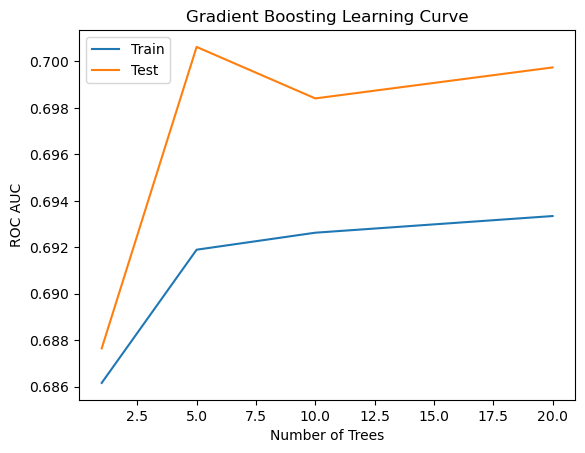

In [43]:
import matplotlib.pyplot as plt

plt.plot(n_estimators_list, train_auc, label="Train")
plt.plot(n_estimators_list, test_auc, label="Test")
plt.xlabel("Number of Trees")
plt.ylabel("ROC AUC")
plt.legend()
plt.title("Gradient Boosting Learning Curve")
plt.show()

In [28]:
for a, b, c in zip(n_estimators_list, train_auc, test_auc):
    print(f'{a} - train auc: {b}; test auc:{c}')

1 - train auc: 0.6861582548557374; test auc:0.6876466970615297
5 - train auc: 0.6918948921451111; test auc:0.7006275495691059
10 - train auc: 0.6926270711866815; test auc:0.6984099111196571
20 - train auc: 0.6933445476144796; test auc:0.6997443875710543


In [42]:
learning_rates = [0.01, 0.05, 0.1, 0.3]
train_lr_auc = []
test_lr_auc = []
for lr in learning_rates:
    model = GradientBoostingClassifier(
        n_estimators=5,
        learning_rate=lr,
        max_depth=3
    )

    model.fit(X_train, y_train)

    pred_train = model.predict_proba(X_train)
    pred_test = model.predict_proba(X_test)
    train_lr_auc.append(roc_auc_score(y_train, pred_train[:,1]))
    test_lr_auc.append(roc_auc_score(y_test, pred_test[:,1]))

for a, b, c in zip(learning_rates, train_lr_auc, test_lr_auc):
    print(f'Learning Rate: {a} - train auc: {b:.3f}; test auc:{c:.3f}')

Learning Rate: 0.01 - train auc: 0.686; test auc:0.688
Learning Rate: 0.05 - train auc: 0.689; test auc:0.695
Learning Rate: 0.1 - train auc: 0.692; test auc:0.701
Learning Rate: 0.3 - train auc: 0.693; test auc:0.699


In [41]:
print(f"Train: Tree auc: {auc_train_tree:.3f}")
print(f"Test: Tree auc: {auc_test_tree:.3f}")

print(f"Train: Bagging auc: {auc_train_bag:.3f}")
print(f"Test: Bagging auc: {auc_test_bag:.3f}")

print(f"Train: RF auc: {auc_train_rf:.3f}")
print(f"Test: RF auc: {auc_test_rf:.3f}")

print(f"Train: GBM auc: {train_lr_auc[2]:.3f}")
print(f"Test: GBM auc: {test_lr_auc[2]:.3f}")

Train: Tree auc: 0.671
Test: Tree auc: 0.663
Train: Bagging auc: 0.695
Test: Bagging auc: 0.700
Train: RF auc: 0.707
Test: RF auc: 0.699
Train: GBM auc: 0.692
Test: GBM auc: 0.701


## Key Observations

From the experiments:

* Training performance improves steadily as more trees are added
* Test performance improves initially, then stabilizes or degrades
* Smaller learning rates require more trees but generalize better

---

## Practical Guidelines

* Use **small learning rates** (e.g., 0.05–0.1)
* Compensate with **more estimators**
* Monitor validation performance to avoid overfitting

---

## Conceptual Takeaway

Gradient Boosting is a **controlled optimization process**:

* Each tree makes a small step
* Too many steps → overfitting
* Too large steps → instability

Balancing these is key to performance.


## Final Comparison: Tree vs Bagging vs Random Forest vs Gradient Boosting

We now compare all models developed in this notebook on the same dataset.

The goal is to understand **how each method modifies the learning process and how these changes affect performance.**.

---

## Summary of Results

| Model             | Train ROC AUC | Test ROC AUC | Key Property              |
| ----------------- | -------------- | ------------- | ------------------------- |
| Decision Tree     | 0.671            | 0.663           | High variance             |
| Bagging           | 0.695            | 0.700           | Variance reduction        |
| Random Forest     | 0.707            | 0.699           | Feature randomness + decorrelation        |
| Gradient Boosting | 0.692            | 0.701           | Sequential bias reduction |

---

## Interpretation

### Decision Tree

The single decision tree achieves the weakest performance.
* Tends to overfit (high train ROC AUC, lower test ROC AUC)
* Sensitive to data variations
* Serves as a **high-variance baseline**

This serves as the baseline from which all ensemble improvements are built.

---

### Bagging

Bagging substantially improves performance over a single tree.
* Improves stability by averaging multiple trees
* Reduces variance significantly
* Limited when trees remain highly correlated

Observations:

- Test ROC AUC increases from 0.663 → 0.700
- Clear evidence of variance reduction

This confirms the main purpose of Bagging:

- Averaging unstable learners produces more stable predictions.

This is the largest improvement observed in the notebook.


---

### Random Forest

* Further improves Bagging by **decorrelating trees**
* More robust generalization
* Strong default model for tabular data

Unfortuntely, in this example, Random Forest slightly improves training performance but does not improve test ROC AUC relative to Bagging.

Observations:

- Highest train ROC AUC (0.707)
- Test ROC AUC similar to Bagging (0.699)

Possible explanation:

- The dataset and feature engineering used here may not benefit strongly from feature subsampling
- Trees may already be sufficiently diverse through bootstrap sampling alone

This highlights an important practical lesson:

- More sophisticated algorithms do not always produce materially better results.

Random Forest introduces additional randomness, but in this particular setting, the gain is minimal.

---

### Gradient Boosting

* Takes a fundamentally different approach:

  * Models are built **sequentially**, not independently
  * Each model corrects previous errors

* Typically achieves:

  * Higher ROC AUC
  * Better bias-variance trade-off

In this example, Gradient Boosting achieves the best test performance, but only marginally.

Observations:

- Best test ROC AUC (0.701)
- Lower train ROC AUC than Random Forest (0.692 vs 0.707)

This is an interesting result.

- Despite not maximizing training ROC AUC, Gradient Boosting generalizes slightly better.

This suggests:

- More efficient allocation of model capacity
- Better bias-variance trade-off

However, the improvement is small.

Possible reasons:

- Simplified implementation
    - This notebook implements a pedagogical version of GBM
    - Real libraries such as XGBoost or LightGBM include:
        - second-order optimization
        - regularization
        - advanced tree growth strategies
        - optimized split finding
- Limited hyperparameter tuning
    - Learning rate, tree depth, and number of estimators strongly affect boosting performance
- Dataset complexity
    - The selected feature subset and preprocessing may limit the advantage of boosting

---

## Key Takeaways

1. **Ensembles improve trees in two distinct ways:**

   * Averaging (Bagging, Random Forest) → reduces variance
   * Sequential learning (Boosting) → reduces bias

---

2. **Random Forest vs Gradient Boosting**

* Random Forest:

  * Easier to tune
  * More robust to noise
  * Parallelizable

* Gradient Boosting:

  * More flexible
  * Often higher performance
  * More sensitive to hyperparameters

---

3. **Why Gradient Boosting Often Wins**

Gradient Boosting directly optimizes the loss function via functional gradient descent.

This allows it to:

* Focus on hard examples
* Iteratively refine predictions
* Achieve strong predictive performance

---

## Final Perspective

We started from a single decision tree and progressively built:

* Bagging → stabilize predictions
* Random Forest → reduce correlation
* Gradient Boosting → optimize predictions

This progression shows that:

> Modern machine learning models are often not fundamentally new algorithms,
> but **carefully designed combinations of simple ideas**.

---


## When to Use Each Model

We conclude with practical guidance on choosing between the models covered in this notebook.

---

## Decision Tree

**Use when:**

* You need interpretability
* You want a fast baseline
* You are exploring feature relationships

**Avoid when:**

* You care about predictive performance
* The dataset is noisy or high-dimensional

---

## Bagging

**Use when:**

* Your base model (tree) is unstable
* You want a simple way to reduce variance

**Limitations:**

* Does not address feature dominance
* Gains may be limited if trees are highly correlated

---

## Random Forest

**Use when:**

* You want a strong, reliable baseline
* Minimal tuning is desired
* You need robustness to noise and overfitting

**Strengths:**

* Good performance out-of-the-box
* Parallelizable
* Low risk of overfitting

---

## Gradient Boosting

**Use when:**

* You want the best possible predictive performance
* You are willing to tune hyperparameters
* You need a model that captures complex patterns

**Strengths:**

* Directly optimizes the loss function
* Focuses on difficult observations
* Highly flexible

**Cautions:**

* Sensitive to:

  * Learning rate
  * Number of estimators
  * Tree depth
* Can overfit if not properly regularized

---

## Practical Rule of Thumb

* Start with **Random Forest** as a baseline
* Move to **Gradient Boosting** if:

  * You need higher perfprmance
  * You can afford tuning

---

## Final Insight

All models in this notebook are built from the same fundamental component:

> **Decision trees**

What differentiates them is not the base learner, but **how multiple learners are combined**:

* Averaging → reduces variance
* Sequential correction → reduces bias

Understanding this distinction is the key to mastering modern ensemble methods.

---

## Closing Thought

Gradient Boosting is often presented as a complex algorithm.

In reality, it is the result of a simple idea applied rigorously:

> Build a model, identify its errors, and iteratively correct them.

This principle extends far beyond trees—and appears across many areas of machine learning.

---

---
